# Caracterização dos volumes CCTA: ImageCAS, OrCaScore e MM-WHS

A comparação quantitativa usa somente imagens CCTA com contraste:

- **OrCaScore:** arquivos `*CTAI.mhd`; os pares `*CTI.mhd` sem contraste não entram nas estatísticas, mas um par do mesmo paciente é mostrado na inspeção visual.
- **MM-WHS:** arquivos `ct_*_image.nii.gz`; volumes de MRI e máscaras `*_label` são excluídos.
- **ImageCAS:** arquivos `*.img.nii.gz`; as máscaras `*.label.nii.gz` não entram no inventário.

A análise descreve inventário, geometria, cobertura física, intensidades HU e aparência das imagens. Os volumes seguem o padrão de `preprocessing_visualization.ipynb`: layout nativo `(x, y, z)`, sem canonicalização automática, e vistas axiais em `volume[:, :, z]` com `origin='upper'`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file()
)
sys.path.insert(0, str(REPO_ROOT / "src"))

from utils.project.ccta_datasets import (  # noqa: E402
    discover_ccta_volumes,
    load_ccta_volume,
    load_mhd_volume_xyz,
    select_representative_exams,
    summarize_ccta_inventory,
)
from utils.project.notebook_env import resolve_existing_path  # noqa: E402
from utils.project.notebook_env import resolve_imagecas_base_path  # noqa: E402

pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
ORCASCORE_PATH = resolve_existing_path(
    "ORCASCORE_BASE_PATH",
    [Path("/media/matheus/HD/DatasetsCCTA/Orca_Score_Calcium")],
    "OrCaScore",
)
MMWHS_PATH = resolve_existing_path(
    "MMWHS_BASE_PATH",
    [Path("/media/matheus/HD/DatasetsCCTA/MM-WHS-2017-Dataset")],
    "MM-WHS 2017",
)
IMAGECAS_PATH = resolve_imagecas_base_path()

print(f"OrCaScore: {ORCASCORE_PATH}")
print(f"MM-WHS:    {MMWHS_PATH}")
print(f"ImageCAS:  {IMAGECAS_PATH}")

OrCaScore: /media/matheus/HD/DatasetsCCTA/Orca_Score_Calcium
MM-WHS:    /media/matheus/HD/DatasetsCCTA/MM-WHS-2017-Dataset
ImageCAS:  /media/matheus/HD/DatasetsCCTA/ImageCAS/1-1000


## 1. Inventário CCTA

O inventário inclui somente os padrões definidos para CCTA; CT sem contraste, MRI e rótulos ficam fora das estatísticas.

In [3]:
inventory = discover_ccta_volumes(ORCASCORE_PATH, MMWHS_PATH, IMAGECAS_PATH)
summary = summarize_ccta_inventory(inventory)

display(summary)

,dataset,exams,train,val,test,full,reported_orientation,matrix_xy,slices_median_min_max,spacing_xy_mm_median_min_max,spacing_z_mm_median_min_max,coverage_z_mm_median_min_max
0,OrCaScore,72,32,0,40,0,RAI,512x512,296 [167; 640],0.429 [0.314; 0.49],0.425 [0.25; 0.625],126 [104; 203]
1,MM-WHS,60,20,0,40,0,"LAS, RAS",512x512,258 [177; 363],0.444 [0.281; 0.586],0.625 [0.45; 0.625],153 [111; 188]
2,ImageCAS,1000,0,0,0,1000,LAS,512x512,275 [166; 277],0.35 [0.289; 0.465],0.5 [0.5; 0.5],138 [83; 138]


In [4]:
display(pd.crosstab(inventory["dataset"], inventory["subset"], margins=True))

subset,full,test,train,All
dataset,,,,
ImageCAS,1000,0,0,1000
MM-WHS,0,40,20,60
OrCaScore,0,40,32,72
All,1000,80,52,1132


In [5]:
display(inventory.head())

,dataset,subset,exam_id,path,file_format,dtype,reported_orientation,size_x,size_y,slice_count,spacing_x_mm,spacing_y_mm,spacing_z_mm,fov_x_mm,fov_y_mm,coverage_z_mm,voxel_volume_mm3
0,OrCaScore,train,TRV1P1,/media/matheus/HD/DatasetsCCTA/Orca_Score_Calc...,MHD/ZRAW,MET_SHORT,RAI,512,512,280,0.412109,0.412109,0.625,210.999808,210.999808,175.00,0.106146
1,OrCaScore,train,TRV1P2,/media/matheus/HD/DatasetsCCTA/Orca_Score_Calc...,MHD/ZRAW,MET_SHORT,RAI,512,512,182,0.416016,0.416016,0.625,213.000192,213.000192,113.75,0.108168
2,OrCaScore,train,TRV1P3,/media/matheus/HD/DatasetsCCTA/Orca_Score_Calc...,MHD/ZRAW,MET_SHORT,RAI,512,512,212,0.386719,0.386719,0.625,198.000128,198.000128,132.50,0.093470
3,OrCaScore,train,TRV1P4,/media/matheus/HD/DatasetsCCTA/Orca_Score_Calc...,MHD/ZRAW,MET_SHORT,RAI,512,512,228,0.488281,0.488281,0.625,249.999872,249.999872,142.50,0.149011
4,OrCaScore,train,TRV1P5,/media/matheus/HD/DatasetsCCTA/Orca_Score_Calc...,MHD/ZRAW,MET_SHORT,RAI,512,512,224,0.445312,0.445312,0.625,227.999744,227.999744,140.00,0.123939


## 2. Geometria e resolução espacial

Os bancos diferem na amostragem e na extensão física. ImageCAS concentra-se em 275 fatias e `0,5 mm` no eixo z; MM-WHS usa principalmente `0,625 mm`; OrCaScore apresenta a maior variação de espaçamento e quantidade de fatias. O FOV no plano explica parte da diferença aparente de zoom.

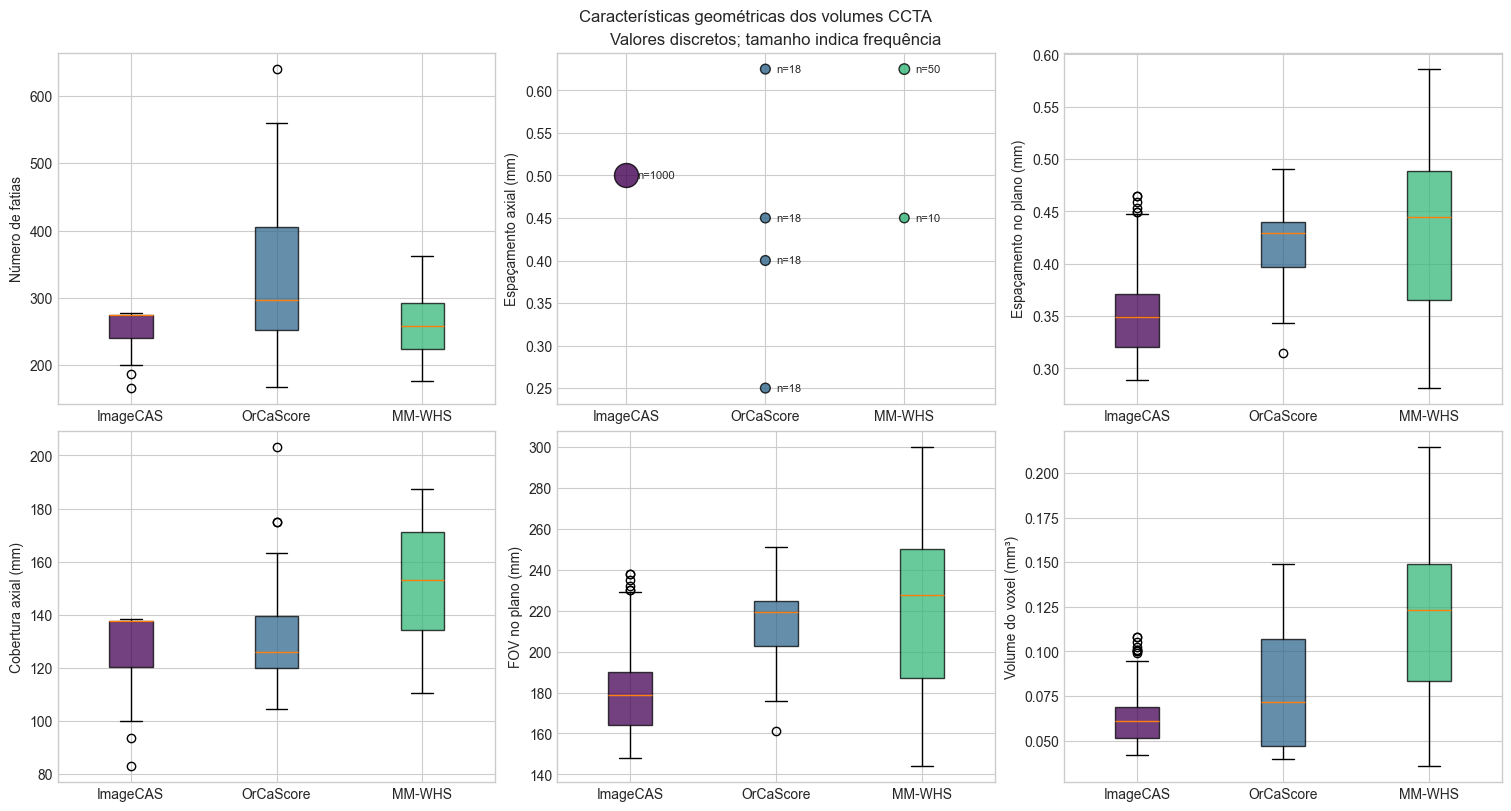

In [6]:
colors = {
    "ImageCAS": "#440154",
    "OrCaScore": "#31688e",
    "MM-WHS": "#35b779",
}
dataset_order = list(colors)
box_metrics = [
    ("slice_count", "Número de fatias"),
    ("spacing_x_mm", "Espaçamento no plano (mm)"),
    ("coverage_z_mm", "Cobertura axial (mm)"),
    ("fov_x_mm", "FOV no plano (mm)"),
    ("voxel_volume_mm3", "Volume do voxel (mm³)"),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
box_axes = [axes[0, 0], axes[0, 2], *axes[1]]
for ax, (column, label) in zip(box_axes, box_metrics, strict=True):
    groups = [inventory.loc[inventory["dataset"].eq(name), column] for name in colors]
    boxes = ax.boxplot(groups, tick_labels=list(colors), patch_artist=True)
    for patch, color in zip(boxes["boxes"], colors.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_ylabel(label)

spacing_ax = axes[0, 1]
spacing_counts = (
    inventory.assign(spacing_z_rounded=inventory["spacing_z_mm"].round(3))
    .groupby(["dataset", "spacing_z_rounded"])
    .size()
)
max_frequency = int(spacing_counts.max())
for position, dataset in enumerate(dataset_order, start=1):
    counts = spacing_counts.loc[dataset]
    spacing_ax.scatter(
        np.full(len(counts), position),
        counts.index,
        s=45 + 255 * counts.to_numpy() / max_frequency,
        color=colors[dataset],
        alpha=0.8,
        edgecolor="black",
    )
    for spacing, count in counts.items():
        spacing_ax.annotate(
            f"n={count}",
            (position, spacing),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=8,
        )
spacing_ax.set(
    xticks=range(1, len(dataset_order) + 1),
    xticklabels=dataset_order,
    ylabel="Espaçamento axial (mm)",
    title="Valores discretos; tamanho indica frequência",
)
spacing_ax.set_xlim(0.5, len(dataset_order) + 0.65)
fig.suptitle("Características geométricas dos volumes CCTA")
plt.show()

## 3. Exemplos de imagens

Cada banco é representado pelo exame mais próximo da mediana da quantidade de fatias. As vistas mostram o início, o centro e o final dos volumes na mesma janela `[-200, 800] HU`.

In [7]:
representatives = select_representative_exams(inventory)
VOLUME_CACHE = {}


def get_volume(record):
    key = str(record["path"])
    if key not in VOLUME_CACHE:
        VOLUME_CACHE[key] = load_ccta_volume(record)
    return VOLUME_CACHE[key]


def axial_views(volume):
    middle = volume.shape[2] // 2
    return [
        ("MIP axial", np.max(volume, axis=2), -200, 1200),
        ("Primeira fatia (0)", volume[:, :, 0], -200, 800),
        (f"Fatia média ({middle})", volume[:, :, middle], -200, 800),
        (f"Última fatia ({volume.shape[2] - 1})", volume[:, :, -1], -200, 800),
    ]


def plot_axial_overview(rows, title):
    fig, axes = plt.subplots(
        len(rows),
        4,
        figsize=(15, 4 * len(rows)),
        squeeze=False,
        constrained_layout=True,
    )
    for row_index, (row_label, volume) in enumerate(rows):
        for ax, (view_title, image, vmin, vmax) in zip(
            axes[row_index], axial_views(volume)
        ):
            ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax, origin="upper")
            ax.set_title(view_title)
            ax.axis("off")
        axes[row_index, 0].text(
            0.02,
            0.98,
            f"{row_label}\n{volume.shape[2]} fatias",
            transform=axes[row_index, 0].transAxes,
            va="top",
            color="white",
            fontsize=10,
            bbox={"facecolor": "black", "alpha": 0.65, "pad": 4},
        )
    fig.suptitle(title, fontsize=14)
    plt.show()

### OrCaScore

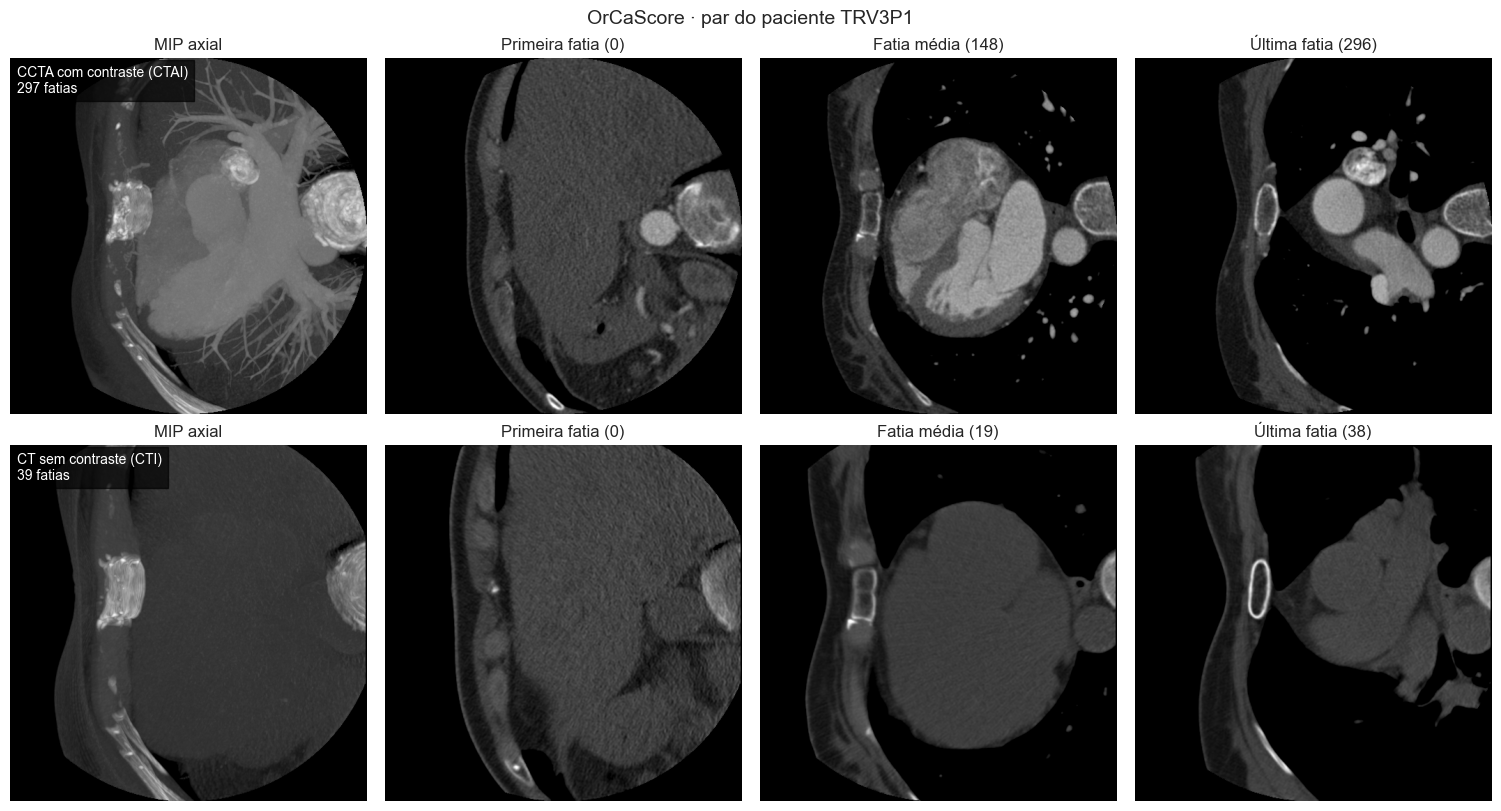

In [8]:
orca_record = (
    representatives.loc[representatives["dataset"].eq("OrCaScore")]
    .reset_index(drop=True)
    .iloc[1]
)
orca_ccta = get_volume(orca_record)
orca_noncontrast_path = Path(orca_record["path"]).with_name(
    Path(orca_record["path"]).name.replace("CTAI.mhd", "CTI.mhd")
)
if orca_noncontrast_path.is_file():
    orca_noncontrast = load_mhd_volume_xyz(orca_noncontrast_path)
    plot_axial_overview(
        [
            ("CCTA com contraste (CTAI)", orca_ccta),
            ("CT sem contraste (CTI)", orca_noncontrast),
        ],
        title=f"OrCaScore · par do paciente {orca_record['exam_id']}",
    )
else:
    print(f"Par CTI ausente; comparação não exibida: {orca_noncontrast_path}")

### MM-WHS

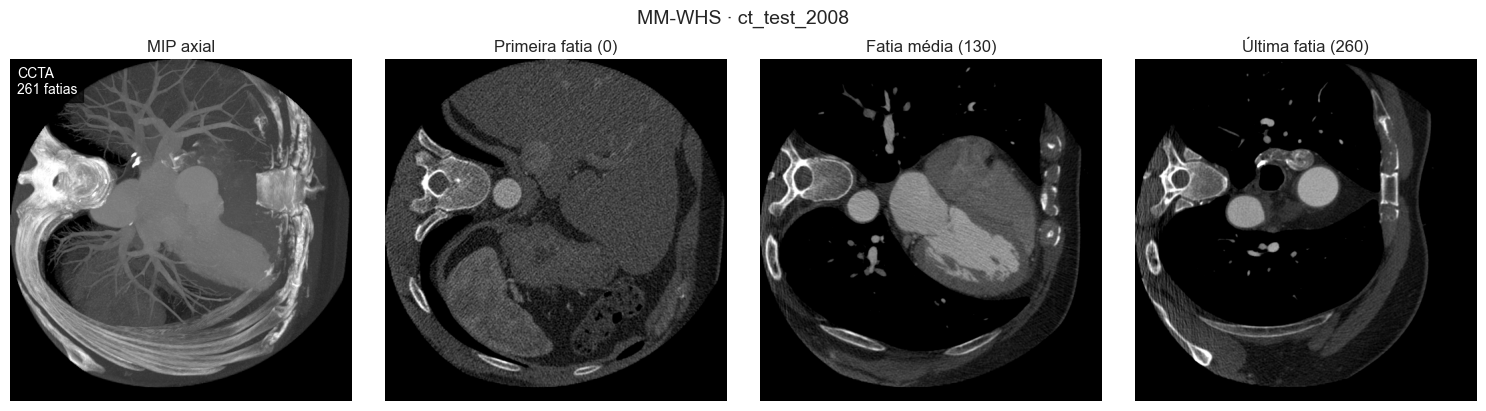

In [9]:
mmwhs_record = (
    representatives.loc[representatives["dataset"].eq("MM-WHS")]
    .reset_index(drop=True)
    .iloc[1]
)
mmwhs_volume = get_volume(mmwhs_record)
plot_axial_overview(
    [("CCTA", mmwhs_volume)],
    title=f"MM-WHS · {mmwhs_record['exam_id']}",
)

### ImageCAS

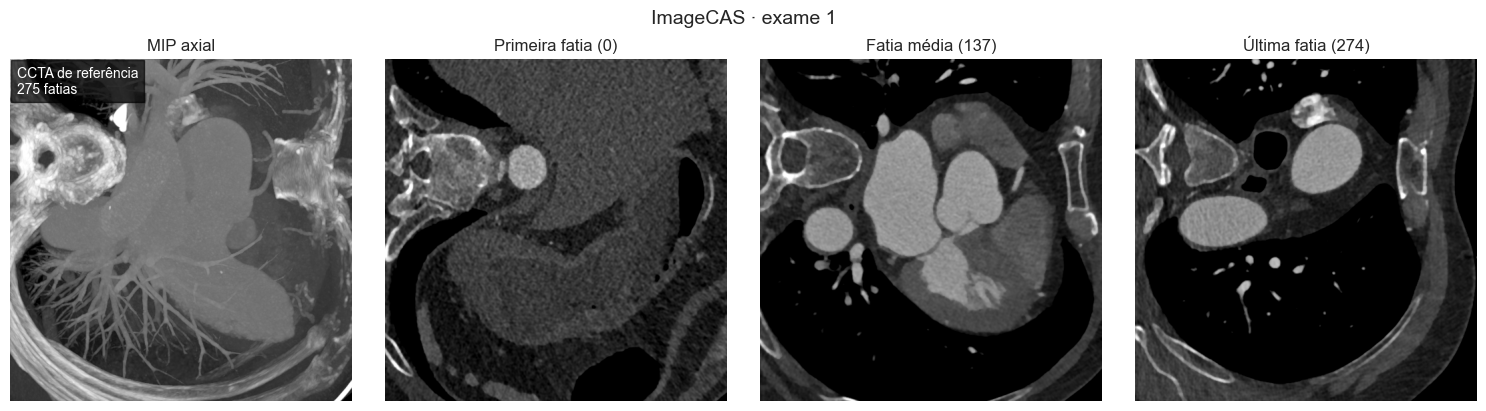

In [10]:
imagecas_record = (
    representatives.loc[representatives["dataset"].eq("ImageCAS")]
    .reset_index(drop=True)
    .iloc[1]
)
imagecas_volume = get_volume(imagecas_record)
plot_axial_overview(
    [("CCTA de referência", imagecas_volume)],
    title=f"ImageCAS · exame {imagecas_record['exam_id']}",
)

### Comparação lado a lado

As colunas representam os bancos e as linhas mostram a primeira, a média e a última fatia do exame mediano de cada banco. A janela de visualização é a mesma nos nove painéis.

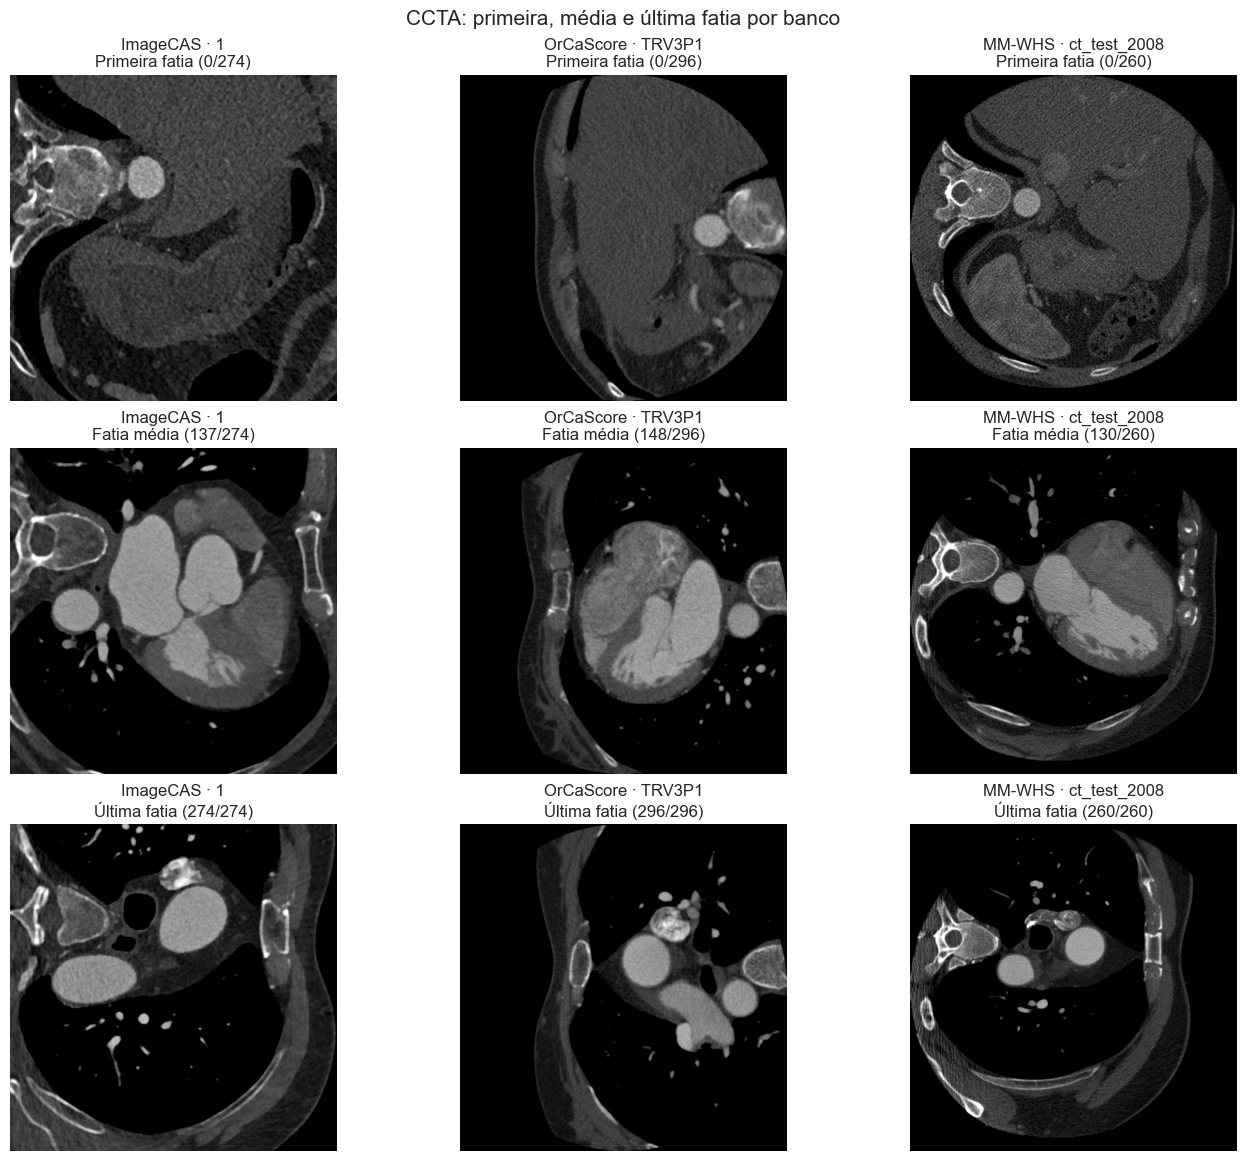

In [11]:
dataset_order = ["ImageCAS", "OrCaScore", "MM-WHS"]
comparison_cases = {
    dataset: representatives.loc[representatives["dataset"].eq(dataset)]
    .reset_index(drop=True)
    .iloc[1]
    for dataset in dataset_order
}
slice_labels = ["Primeira fatia", "Fatia média", "Última fatia"]
fig, axes = plt.subplots(3, 3, figsize=(13.5, 11.5), constrained_layout=True)
for col, dataset in enumerate(dataset_order):
    record = comparison_cases[dataset]
    volume = get_volume(record)
    slice_indices = [0, volume.shape[2] // 2, volume.shape[2] - 1]
    for row, (slice_label, slice_index) in enumerate(
        zip(slice_labels, slice_indices, strict=True)
    ):
        axes[row, col].imshow(
            volume[:, :, slice_index],
            cmap="gray",
            vmin=-200,
            vmax=800,
            origin="upper",
        )
        axes[row, col].set_title(
            f"{dataset} · {record['exam_id']}\n"
            f"{slice_label} ({slice_index}/{volume.shape[2] - 1})"
        )
        axes[row, col].axis("off")
fig.suptitle("CCTA: primeira, média e última fatia por banco", fontsize=15)
plt.show()

### Efeito do campo de visão

Nos volumes brutos, o FOV maior do OrCaScore e do MM-WHS reduz visualmente as estruturas cardíacas. O recorte central comum de aproximadamente `193 mm` elimina essa diferença de enquadramento sem interpolar ou modificar os arquivos.

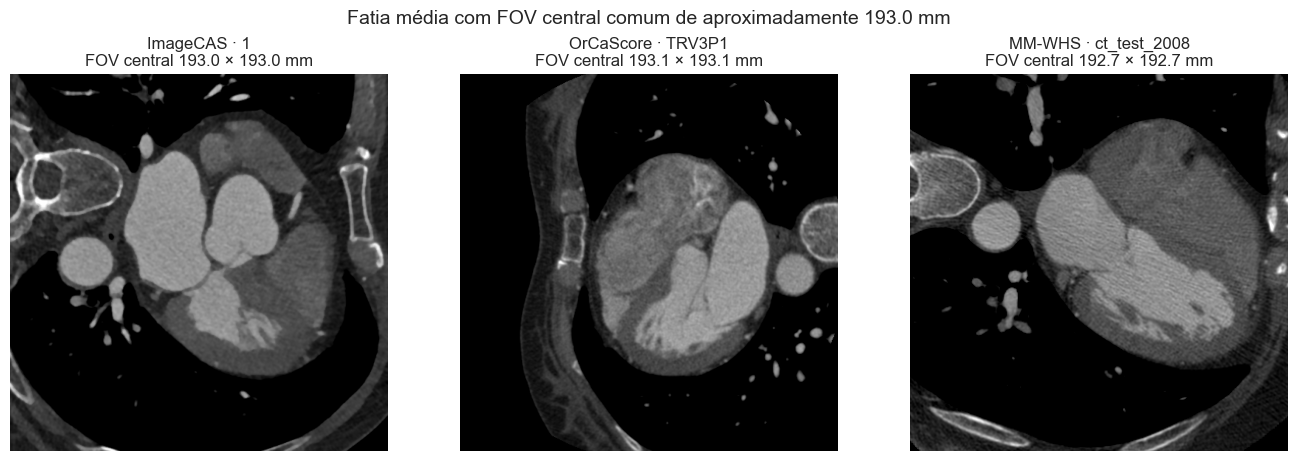

In [12]:
def center_crop_to_fov(volume, spacing_x, spacing_y, target_fov_mm):
    size_x = min(volume.shape[0], round(target_fov_mm / spacing_x))
    size_y = min(volume.shape[1], round(target_fov_mm / spacing_y))
    start_x = (volume.shape[0] - size_x) // 2
    start_y = (volume.shape[1] - size_y) // 2
    return volume[start_x : start_x + size_x, start_y : start_y + size_y, :]


target_fov_mm = min(
    min(float(record["fov_x_mm"]), float(record["fov_y_mm"]))
    for record in comparison_cases.values()
)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5), constrained_layout=True)
for ax, dataset in zip(axes, dataset_order, strict=True):
    record = comparison_cases[dataset]
    volume = get_volume(record)
    cropped = center_crop_to_fov(
        volume,
        float(record["spacing_x_mm"]),
        float(record["spacing_y_mm"]),
        target_fov_mm,
    )
    middle = cropped.shape[2] // 2
    ax.imshow(
        cropped[:, :, middle],
        cmap="gray",
        vmin=-200,
        vmax=800,
        origin="upper",
    )
    actual_fov_x = cropped.shape[0] * float(record["spacing_x_mm"])
    actual_fov_y = cropped.shape[1] * float(record["spacing_y_mm"])
    ax.set_title(
        f"{dataset} · {record['exam_id']}\n"
        f"FOV central {actual_fov_x:.1f} × {actual_fov_y:.1f} mm"
    )
    ax.axis("off")
fig.suptitle(
    f"Fatia média com FOV central comum de aproximadamente {target_fov_mm:.1f} mm",
    fontsize=14,
)
plt.show()

## 4. Orientação anatômica e referência ImageCAS

Os cabeçalhos classificam todos os ImageCAS como `LAS`, 58 MM-WHS como `LAS`, dois MM-WHS como `RAS` e todos os OrCaScore como `RAI`. As figuras preservam a ordem nativa dos voxels e mostram o OrCaScore invertido horizontalmente em relação à apresentação do ImageCAS.

In [13]:
orientation_table = (
    inventory.groupby(["dataset", "reported_orientation"], as_index=False)
    .size()
    .rename(columns={"size": "exams"})
)
display(orientation_table)

,dataset,reported_orientation,exams
0,ImageCAS,LAS,1000
1,MM-WHS,LAS,58
2,MM-WHS,RAS,2
3,OrCaScore,RAI,72


### Análise da orientação visual

A comparação visual mostra o OrCaScore invertido horizontalmente em relação ao ImageCAS. No layout usado pelo notebook, `(x, y, z)`, a correção corresponde a `volume[:, ::-1, :]`: somente o eixo 1 é invertido. A transformação mantém o eixo 0, a ordem das fatias e os valores dos voxels. Ela padroniza a apresentação das imagens, mas não substitui uma reorientação física baseada na matriz de direção.

### Correção da orientação visual

Os três pares mostram a mesma fatia antes e depois da inversão horizontal, aplicada no eixo 1. Os eixos 0 e z permanecem inalterados.

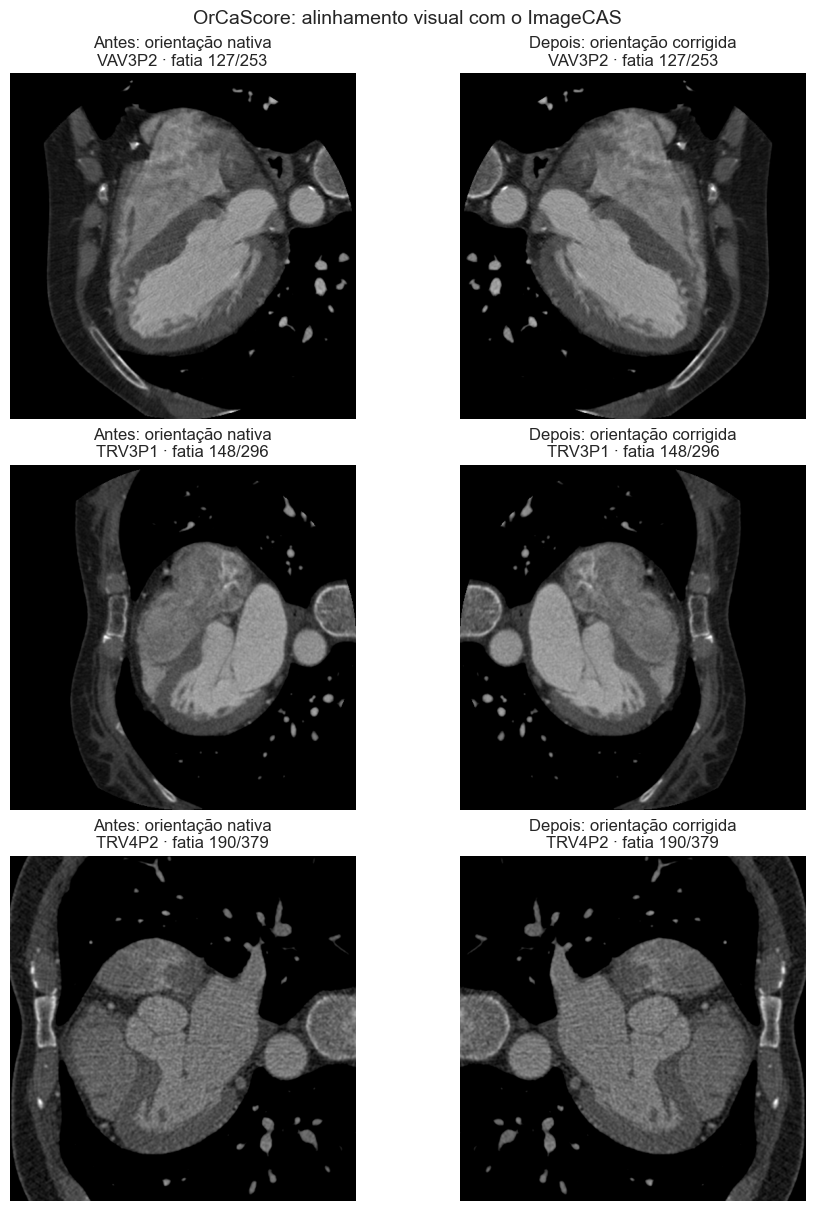

In [14]:
def correct_orcascore_visual_orientation(record, volume):
    """Flip the OrCaScore second axis for consistent visual display."""
    if record["dataset"] == "OrCaScore":
        return volume[:, ::-1, :]
    return volume


orca_examples = representatives.loc[
    representatives["dataset"].eq("OrCaScore")
].reset_index(drop=True)
fig, axes = plt.subplots(3, 2, figsize=(9, 12), constrained_layout=True)
for row, (_, record) in enumerate(orca_examples.iterrows()):
    original = get_volume(record)
    corrected = correct_orcascore_visual_orientation(record, original)
    middle = original.shape[2] // 2
    for ax, image, stage in zip(
        axes[row],
        [original[:, :, middle], corrected[:, :, middle]],
        ["Antes: orientação nativa", "Depois: orientação corrigida"],
        strict=True,
    ):
        ax.imshow(image, cmap="gray", vmin=-200, vmax=800, origin="upper")
        ax.set_title(
            f"{stage}\n{record['exam_id']} · fatia {middle}/{original.shape[2] - 1}"
        )
        ax.axis("off")
fig.suptitle("OrCaScore: alinhamento visual com o ImageCAS", fontsize=14)
plt.show()

## 5. Distribuição de intensidades

Para limitar memória e tempo, o gráfico usa uma amostra uniforme de até 150 mil voxels por exame representativo. A faixa exibida (`-1000` a `1500 HU`) cobre ar, pulmão, gordura, tecidos moles, contraste e cálcio; valores extremos permanecem nos volumes originais.

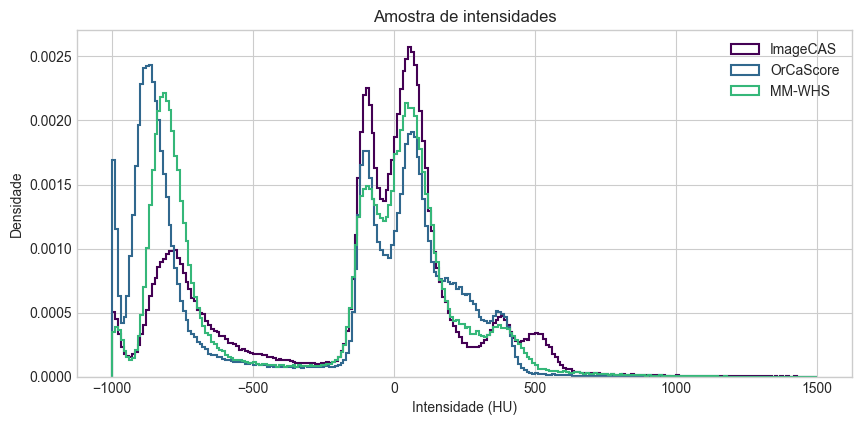

,count,mean,std,median,min,max
dataset,,,,,,
ImageCAS,443715,-140.1,401.8,-25.0,-1000.0,1488.0
MM-WHS,347582,-246.6,438.7,-74.0,-1000.0,1321.0
OrCaScore,373920,-308.6,471.9,-101.0,-1000.0,1477.0


In [15]:
rng = np.random.default_rng(42)
samples = []
for _, record in representatives.iterrows():
    values = get_volume(record).reshape(-1)
    if values.size > 150_000:
        values = values[rng.choice(values.size, 150_000, replace=False)]
    values = values[np.isfinite(values)]
    values = values[(values >= -1000) & (values <= 1500)]
    samples.append(
        pd.DataFrame({"dataset": record["dataset"], "hu": values.astype(float)})
    )
hu_sample = pd.concat(samples, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
bins = np.linspace(-1000, 1500, 251)
for dataset, color in colors.items():
    values = hu_sample.loc[hu_sample["dataset"].eq(dataset), "hu"]
    ax.hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=1.5,
        color=color,
        label=dataset,
    )
ax.set(xlabel="Intensidade (HU)", ylabel="Densidade", title="Amostra de intensidades")
ax.legend()
plt.show()

display(
    hu_sample.groupby("dataset")["hu"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .round(1)
)

## 6. Síntese dos resultados

- **Geometria:** ImageCAS tem FOV mediano próximo de `179 mm`, contra aproximadamente `220 mm` no OrCaScore e `228 mm` no MM-WHS. O maior FOV explica o aspecto mais afastado desses bancos.
- **Amostragem:** ImageCAS usa `0,5 mm` no eixo z; MM-WHS concentra-se em `0,625 mm`; OrCaScore apresenta maior variedade. Quantidade de fatias e cobertura física, portanto, não são equivalentes.
- **Orientação:** ImageCAS é uniformemente `LAS`, MM-WHS contém `LAS` e `RAS`, e OrCaScore reporta `RAI`. Na visualização nativa, a inversão do eixo 1 alinha o OrCaScore ao ImageCAS sem alterar os eixos 0 e z.
- **Domínio:** resolução, FOV e distribuição HU diferem entre as coortes, além das diferenças de orientação.
- **Rótulos:** ImageCAS fornece máscaras coronárias; MM-WHS, estruturas cardíacas; e as referências do OrCaScore pertencem ao CT sem contraste. As estatísticas deste notebook usam somente CCTA.